# Ensemble Models

**Working Example.** Copy this file, rename it, and modify *your* copy.
See earlier notebooks for more information. 

- Author: Denise Case, Kim Hummel
- Date: 2026-06
- Dataset: Seaborn Penguins
- Target: species


## M5. Ensemble Models

This notebook fits a single model and 
two ensembles and 
reports their test scores side by side. 

The analyst decides whether an ensemble's extra complexity is earned, that is, 
whether it creates a real gain, 
rather than just noise.

Every time we fit a model, we use the same shape: 
setup, load, prepare, model, evaluate, summarize.

Judgment always remains with the analyst.

An **ensemble** combines many models 
so their errors partly cancel. 

This module reuses the Module 3 classification setup and asks one question: 

- Does combining models beat the single model in this problem?

## Overview

This project uses the penguins dataset.
We choose to predict the target `species`.
This target is a **discrete category**, so we have a:

- supervised ML problem (because we've chosen a target)
- an ensemble model because we are choosing to combine approaches to see if we can improve on the classification model in Module 3.

Customize the overview in your copy to reflect your dataset and choices.

## A. Prepare the Project Environment (.venv/)

- Open one project in VS Code at a time.
- Prepare the .venv/: specify Python version and install / upgrade dependencies listed in `pyproject.toml`.
- Open an integrated terminal (PowerShell if Windows) in the **root project** folder and run:

```shell
uv self update
uv python pin 3.14
uv lock --upgrade
uv sync --extra dev --extra docs --upgrade
```

## B. Select the Notebook Kernel

- Click on the **Select Kernel** name in the top-right corner of the notebook interface.
- Choose Python Environments... /
- Choose the recommended local .venv/ from the drop-down menu.
- This will create a new kernel for the notebook and allow the notebook to use packages installed in the .venv/ environment.

## C. Working in Notebooks (Custom Notes)

- To run a cell, press **Ctrl+Enter** (or **Cmd+Enter** on Mac) when done editing the cell.
- Change the type of a cell (e.g., code or markdown) by looking in the lower left corner of the notebook interface.
- Rearrange cells by dragging and dropping them within the notebook.

See [Run Jupyter Notebooks](https://denisecase.github.io/pro-analytics-02/workflow-b-apply-example-project/run-notebook/) for:

- how to **copy a notebook**
- how to release a `project.log` file
- how to deal with a **stuck kernel**
- etc.

## Section 0. Ensemble Models and When To Use

A single decision tree can be unstable:
small data changes swing it. 

**Ensembles** fit many models and combine them:

- **Random forest** - many trees on random subsets of rows and features; they vote.
- **Gradient boosting** - trees added in sequence, each correcting the last one's errors.

Ensembles often improve accuracy and stability - but not always.

They cost more to train and are harder to explain. 

The right question is:

Did it earn its complexity *on held-out data* for this problem?

It is a judgment that the analyst makes and defends by comparing test scores.

## Section 1. Project Setup and Imports

In [6]:
# === Section 1a. DECLARE IMPORTS ===

from importlib.metadata import version  # to verify
import logging  # for type hinting
from pathlib import Path
import platform  # to verify
from typing import Final  # for type hinting

from datafun_toolkit.logger import get_logger, log_header
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.ensemble import GradientBoostingClassifier, RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeClassifier

# === Section 1b. CONFIGURE LOGGER ONCE PER NOTEBOOK ===

LOG: logging.Logger = get_logger("M05", level="DEBUG")
log_header(LOG, "M05")


# === Section 1c. USE THE LOGGER TO VERIFY IMPORTS ===

# If any do NOT return a version number, then that package is not installed correctly.
# Check your pyproject.toml and re-run environment setup commands.

LOG.info("Confirming installation:")
LOG.info(f"  python:       {platform.python_version()}")
LOG.info(f"  pandas:       {version('pandas')}")
LOG.info(f"  numpy:        {version('numpy')}")
LOG.info(f"  scikit-learn: {version('scikit-learn')}")
LOG.info(f"  seaborn:      {version('seaborn')}")
LOG.info(f"  matplotlib:   {version('matplotlib')}")


# === Section 1d. SET PANDAS DISPLAY CONFIGURATION (helps in notebooks) ===

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 120)

2026-08-01 09:55:57 | INFO | M05 | === RUN START ===
2026-08-01 09:55:57 | INFO | M05 | project=M05
2026-08-01 09:55:57 | INFO | M05 | repo_dir=ml-05-ensembles
2026-08-01 09:55:57 | INFO | M05 | python=3.14.3
2026-08-01 09:55:57 | INFO | M05 | os=Windows 11
2026-08-01 09:55:57 | INFO | M05 | shell=powershell
2026-08-01 09:55:57 | INFO | M05 | cwd=notebooks
2026-08-01 09:55:57 | INFO | M05 | github_actions=False
2026-08-01 09:55:57 | INFO | M05 | Confirming installation:
2026-08-01 09:55:57 | INFO | M05 |   python:       3.14.3
2026-08-01 09:55:57 | INFO | M05 |   pandas:       3.0.5
2026-08-01 09:55:57 | INFO | M05 |   numpy:        2.5.1
2026-08-01 09:55:57 | INFO | M05 |   scikit-learn: 1.9.0
2026-08-01 09:55:57 | INFO | M05 |   seaborn:      0.13.2
2026-08-01 09:55:57 | INFO | M05 |   matplotlib:   3.11.1


## Section 2. Load and Prepare the Data

In [11]:
# === Section 2. Load and Prepare the Data ===

ROOT_DIR: Final[Path] = Path.cwd().parent  # go up from /notebooks to project root
DATA_DIR: Final[Path] = ROOT_DIR / "data" / "raw"
NOTEBOOK_DIR: Final[Path] = ROOT_DIR / "notebooks"

DATASET_NAME: Final[Path] = DATA_DIR / "diabetes_data.csv"

LOG.info(f"Loading dataset: {DATASET_NAME}")
df: pd.DataFrame = pd.read_csv(DATASET_NAME)
LOG.info(f"Loaded: {df.shape[0]} rows (instances), {df.shape[1]} columns")

# CUSTOM: ANALYST CHOICE - the categorical target to classify.
TARGET_COL: Final[str] = "outcome"

# CUSTOM: Numeric features used to predict the target.
FEATURE_COLS: Final[list[str]] = [
    "glucose",
    "blood_pressure",
    "skin_thickness",
    "BMI",
    "age",
]

required: list[str] = [TARGET_COL, *FEATURE_COLS]
df_model: pd.DataFrame = df.dropna(subset=required).copy()

LOG.info(f"Original rows: {df.shape[0]}")
LOG.info(f"Model rows:    {df_model.shape[0]}")
LOG.info(f"Classes in target '{TARGET_COL}': {sorted(df_model[TARGET_COL].unique())}")
LOG.debug(f"Class counts:\n{df_model[TARGET_COL].value_counts()}")

2026-08-01 10:19:13 | INFO | M05 | Loading dataset: c:\Repos\Applied_Machine_Learning\ml-05-ensembles\data\raw\diabetes_data.csv
2026-08-01 10:19:13 | INFO | M05 | Loaded: 768 rows (instances), 9 columns
2026-08-01 10:19:13 | INFO | M05 | Original rows: 768
2026-08-01 10:19:13 | INFO | M05 | Model rows:    768
2026-08-01 10:19:13 | INFO | M05 | Classes in target 'outcome': [np.int64(0), np.int64(1)]
2026-08-01 10:19:13 | DEBUG | M05 | Class counts:
outcome
0    500
1    268
Name: count, dtype: int64


## Section 3. Split into Train and Test

ANALYST CHOICE

We hold out a test set the model never sees, 
so the score reflects new data.

`stratify=y`

keeps each class in the same proportion across train and test, 
which matters when classes are uneven. 

Whether and how to stratify is a decision for the analyst.

In [12]:
# === Section 3. Split into Train and Test ===

# CUSTOM: ANALYST CHOICE

# Reproducibility for the split and the model.
# Pick any integer, but keep it the same to get the same results.
RANDOM_STATE: Final[int] = 42

"""Build X and y, then split into stratified train and test sets.

WHY: Scoring on held-out data is the only
honest estimate of performance on new data.
Stratifying preserves the class balance in both splits.
"""
X: pd.DataFrame = df_model[FEATURE_COLS]
y: pd.Series = df_model[TARGET_COL]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y
)
LOG.info(f"Train instances: {len(X_train)}")
LOG.info(f"Test instances: {len(X_test)}")

2026-08-01 10:20:02 | INFO | M05 | Train instances: 614
2026-08-01 10:20:02 | INFO | M05 | Test instances: 154


## Section 4. Fit a Single Model and Two Ensembles

ANALYST CHOICE

The baseline is a single decision tree. 

The ensembles are a random forest and a gradient-boosting model. 

The analyst must tune their settings (n_estimators, max_depth, ...).

We fit sensible defaults so you can compare them fairly.

In [28]:
# === Section 4. Fit a Single Model and Two Ensembles ===

"""Fit one single model and two ensembles
on the same training data.

WHY: A fair comparison needs the
 same training data and the same split.
 We fit a single tree as the baseline,
 then two ensembles to compare against it.
"""
LOG.info("Fitting single tree + two ensembles")

modelA = DecisionTreeClassifier(max_depth=4, random_state=RANDOM_STATE)
modelA.fit(X_train, y_train)
LOG.debug("  fitted: single_tree")

modelB = RandomForestClassifier(n_estimators=100, random_state=RANDOM_STATE)
modelB.fit(X_train, y_train)
LOG.debug("  fitted: random_forest")

modelC = GradientBoostingClassifier(random_state=RANDOM_STATE)
modelC.fit(X_train, y_train)
LOG.debug("  fitted: gradient_boosting")

2026-08-01 10:24:12 | INFO | M05 | Fitting single tree + two ensembles
2026-08-01 10:24:12 | DEBUG | M05 |   fitted: single_tree
2026-08-01 10:24:13 | DEBUG | M05 |   fitted: random_forest
2026-08-01 10:24:13 | DEBUG | M05 |   fitted: gradient_boosting


## Section 5. Compare on Held-Out Data

2026-08-01 10:24:17 | INFO | M05 |   single_tree        test accuracy = 0.805
2026-08-01 10:24:17 | INFO | M05 |   random_forest      test accuracy = 0.766
2026-08-01 10:24:17 | INFO | M05 |   gradient_boosting  test accuracy = 0.747


C:\Users\kehum\AppData\Local\Temp\ipykernel_5132\2508383203.py:42: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=x_keys, y=y_values, palette="viridis")


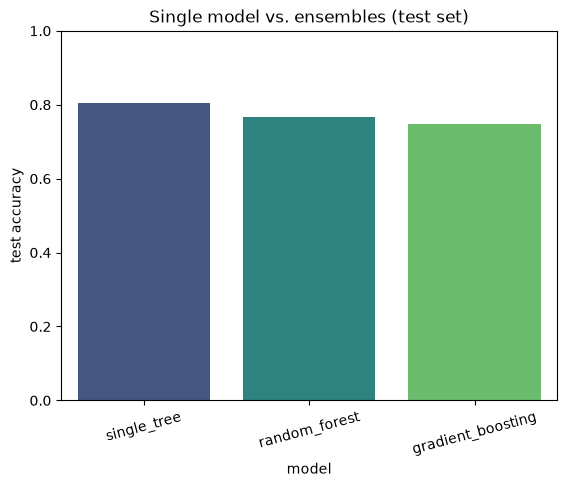

2026-08-01 10:24:17 | INFO | M05 | Best model: single_tree with test accuracy = 0.805


In [29]:
# === Section 5. Compare on Held-Out Data ===

"""Score every model on the same test set and chart the results.

WHY: The only fair comparison is on data none of them trained on.

Code only reports numbers.

Whether an ensemble's gain
is large enough to justify its cost
depends on this specific problem,
and requires analyst judgment.
"""

# score each model on the held-out test set
# accuracy_score returns a numpy scalar - wrap in float() for compatibility
acc_single_tree: float = float(accuracy_score(y_test, modelA.predict(X_test)))
acc_random_forest: float = float(accuracy_score(y_test, modelB.predict(X_test)))
acc_gradient_boosting: float = float(accuracy_score(y_test, modelC.predict(X_test)))

LOG.info(f"  {'single_tree':18s} test accuracy = {acc_single_tree:.3f}")
LOG.info(f"  {'random_forest':18s} test accuracy = {acc_random_forest:.3f}")
LOG.info(f"  {'gradient_boosting':18s} test accuracy = {acc_gradient_boosting:.3f}")

# build a dict for charting
# The keys are the model names,
# and the values are the test accuracies.
scores: dict[str, float] = {
    "single_tree": acc_single_tree,
    "random_forest": acc_random_forest,
    "gradient_boosting": acc_gradient_boosting,
}

# start a new figure
plt.figure()

# create a bar chart of the scores
x_keys = list(scores.keys())
y_values = list(scores.values())

# create a bar chart with seaborn (uses matplotlib under the hood)
sns.barplot(x=x_keys, y=y_values, palette="viridis")

# set y-axis limits to [0, 1] since accuracy is a percentage
plt.ylim(0, 1)

# label the axes and title
plt.xlabel("model")
plt.ylabel("test accuracy")
plt.title("Single model vs. ensembles (test set)")

# slight rotation for readability (optional)
plt.xticks(rotation=15)

# show the plot
plt.show()

# find the best model by name (the one with the highest test accuracy)
best: str = max(scores, key=scores.get)  # type: ignore[arg-type]
LOG.info(f"Best model: {best} with test accuracy = {scores[best]:.3f}")

### Interpretation

Did the ensemble beat the single tree by enough to justify its cost?

In this situation, the single tree beat out the ensembles by 0.04 or more. It does not justify the cost.

## Section 6. Which Features Did the Forest Rely On?

2026-08-02 11:34:02 | INFO | M05 | Random forest feature importances (high to low):
2026-08-02 11:34:02 | INFO | M05 |   glucose              0.356
2026-08-02 11:34:02 | INFO | M05 |   BMI                  0.235
2026-08-02 11:34:02 | INFO | M05 |   age                  0.179
2026-08-02 11:34:02 | INFO | M05 |   blood_pressure       0.121
2026-08-02 11:34:02 | INFO | M05 |   skin_thickness       0.109


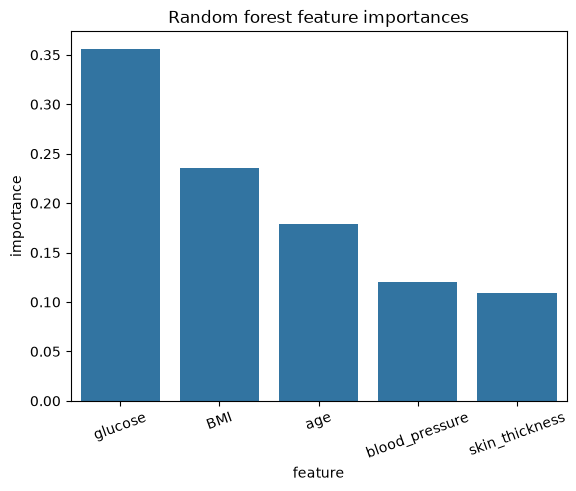

In [30]:
# === Section 6. Feature Importances (Random Forest) ===


"""Chart the random forest's feature importances.

WHY: a forest can still report which features it leaned on.
Importances are a clue, not proof of causation.

"""
# get the feature importances
# from the fitted random forest model
importances: np.ndarray = modelB.feature_importances_

# argsort returns indices that would sort the array ascending
# [::-1] reverses it so the most important feature comes first
order: np.ndarray = np.argsort(importances)[::-1]
LOG.info("Random forest feature importances (high to low):")
for i in order:
    LOG.info(f"  {FEATURE_COLS[i]:20s} {importances[i]:.3f}")

# start a new figure
plt.figure()

# create x and y values for the bar chart, ordered from high to low importance
x_values = [FEATURE_COLS[i] for i in order]
y_values = importances[order]

# create a bar chart of the importances, ordered from high to low
sns.barplot(x=x_values, y=y_values)

# label the axes and title
plt.xlabel("feature")
plt.ylabel("importance")
plt.title("Random forest feature importances")

# slight rotation for readability (optional)
plt.xticks(rotation=20)

# show the plot
plt.show()

## Section 7. Summary and Next Steps

First, output key information (may use Python)
Second, provide your narrative, conclusions, and next steps (in Markdown)

In [31]:
# === Python Summary ===

"""Record what was compared and the judgment still owed."""
LOG.info("========================")
LOG.info("SUMMARY")
LOG.info("========================")
LOG.info(f"Dataset: {DATASET_NAME}   Target: {TARGET_COL} (classification)")
LOG.info("Compared: single tree vs. random forest vs. gradient boosting")
LOG.info("========================")

2026-08-02 11:34:43 | INFO | M05 | ========================
2026-08-02 11:34:43 | INFO | M05 | SUMMARY
2026-08-02 11:34:43 | INFO | M05 | ========================
2026-08-02 11:34:43 | INFO | M05 | Dataset: c:\Repos\Applied_Machine_Learning\ml-05-ensembles\data\raw\diabetes_data.csv   Target: outcome (classification)
2026-08-02 11:34:43 | INFO | M05 | Compared: single tree vs. random forest vs. gradient boosting
2026-08-02 11:34:43 | INFO | M05 | ========================



### Custom Narrative

We compared the single tree vs an ensemble for classification of people that had diabetes. With this dataset from Kaggle, the single tree beat out the ensembles by 0.04. This means that the extra training cost is not worth it. 

A person's glucose level had the greatest importance on the classification. This was not a surprise, as the entire list of features in greatest to leas importance was not a surprise either. It would make sense that a high glucose level would predict diabetes, and having a lower BMI as well as being younger are well know preventative factors for type 2 diabetes. 

### Next Steps

Next steps could be to fine tune what glucose number predicted diabetes. We could also get more data as to how often people's glucose levels were at that value. We could look at if there is any variation during a day or week that would produce different levels that might offer different predictions. 
